In [2]:
import floralarea
from floralarea.cv import yolov8, img_processing as ip
import json
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [10]:
# Load config
with open('../../config/config.json') as f:
    config = json.load(f)

In [11]:
model = yolov8(
    config['flower_model'],
    config['reference_object_model']
)

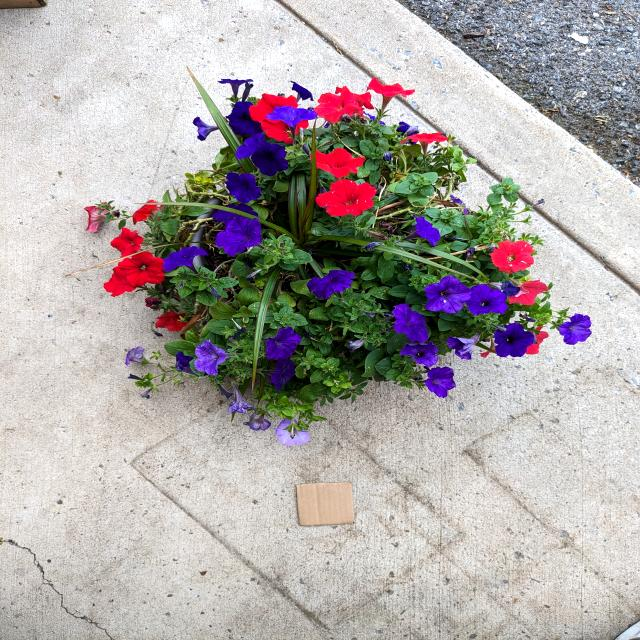

In [21]:
# Preprocess image
filename = '/Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/test_image2.jpg'
ip.apply_preprocessing(filename)

In [22]:
# Estimate floral area
component_area, image = floralarea.cv.runTilles(
    model, 
    filename, 
    threshold=0.5, 
    num_tiles=2, 
    component='flower'
)


image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/notebooks/data/tiles/tile_0_0.jpg: 640x640 22 flowers, 412.0ms
Speed: 7.9ms preprocess, 412.0ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/notebooks/data/tiles/tile_0_1.jpg: 640x640 17 flowers, 243.7ms
Speed: 1.4ms preprocess, 243.7ms inference, 16.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/notebooks/data/tiles/tile_1_0.jpg: 640x640 8 flowers, 226.2ms
Speed: 1.3ms preprocess, 226.2ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/notebooks/data/tiles/tile_1_1.jpg: 640x640 7 flowers, 221.5ms
Speed: 1.3ms preprocess, 221.5ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)


In [28]:
results = model.runInference(filename, 'reference_object', 0.5)
mask = model.getMask(results)
reference_pixel_area = ip.getPixelArea(mask)


image 1/1 /Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/test_image2.jpg: 640x640 2 reference_objects, 301.4ms
Speed: 1.1ms preprocess, 301.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


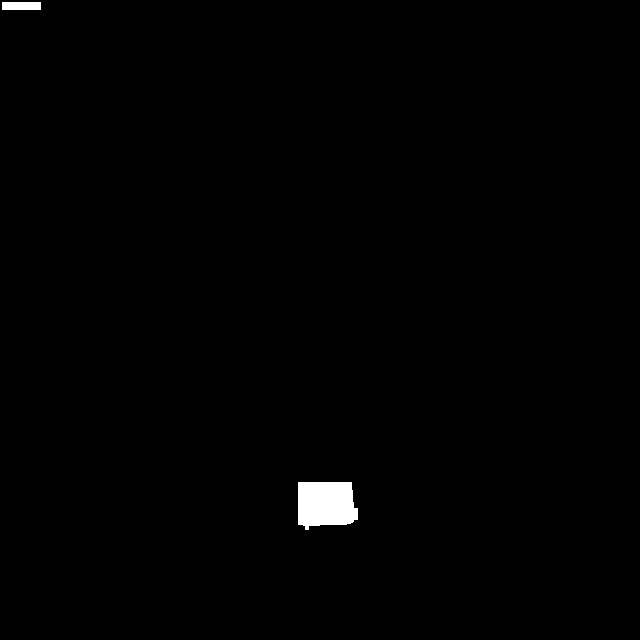

In [29]:
mask 